In [2]:
import os

# Controlla se Conda è già presente nella sessione corrente
if not os.path.exists("/usr/local/miniconda"):
    print("⚙️ Inizializzazione ambiente Conda e mmdet3d...")
    !wget -q https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -O /tmp/miniconda.sh
    !bash /tmp/miniconda.sh -b -p /usr/local/miniconda
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]

    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/main
    !conda tos accept --override-channels --channel https://repo.anaconda.com/pkgs/r
    
    !conda create -n openmmlab python=3.10 -y
    !conda run -n openmmlab pip install "numpy<2"
    !conda run -n openmmlab pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cu118
    !conda run -n openmmlab pip install -U openmim
    !conda run -n openmmlab mim install mmengine "mmcv>=2.0.0rc4,<2.1.0" "mmdet>=3.0.0,<3.1.0"
    
    if not os.path.exists('/content/mmdetection3d'):
        !git clone https://github.com/open-mmlab/mmdetection3d.git -b dev-1.x /content/mmdetection3d
        %cd /content/mmdetection3d
        !conda run -n openmmlab pip install --no-build-isolation .
        %cd /content
    #!conda run -n openmmlab pip install "numpy<2"
    print("✅ Ambiente creato con successo!")
else:
    os.environ["PATH"] = "/usr/local/miniconda/bin:" + os.environ["PATH"]
    print("⚡ Ambiente Conda già pronto!")

⚙️ Inizializzazione ambiente Conda e mmdet3d...
PREFIX=/usr/local/miniconda
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please verify that your PYTHONPATH only points to
    directories of packages that are compatible with the Python interpreter
    in Miniconda3: /usr/local/miniconda
accepted Terms of Service for https://repo.anaconda.com/pkgs/main
accepted Terms of Service for https://repo.anaconda.com/pkgs/r
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.7.1
    latest version: 26.9.1

Please updat

In [3]:
!conda run -n openmmlab python -c "import torch, mmcv, mmengine, mmdet, mmdet3d; print('torch:', torch.__version__); print('mmcv:', mmcv.__version__); print('mmengine:', mmengine.__version__); print('mmdet:', mmdet.__version__); print('mmdet3d:', mmdet3d.__version__); print('CUDA:', torch.cuda.is_available()); print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')"

torch: 2.0.1+cu118
mmcv: 2.0.1
mmengine: 0.10.7
mmdet: 3.0.0
mmdet3d: 1.4.0
CUDA: False
GPU: NONE


In [4]:
!conda run -n openmmlab pip install ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 55.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.2/888.2 kB 35.3 MB/s  0:00:00



In [6]:
!conda run -n openmmlab python -m ipykernel install \
    --user \
    --name openmmlab \
    --display-name "Python (OpenMMLab)"

Installed kernelspec openmmlab in /root/.local/share/jupyter/kernels/openmmlab


In [4]:
import sys
import os

# 1. Rileva se l'esecuzione avviene su Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("⚡ Esecuzione su Google Colab.")
    from google.colab import drive
    drive.mount('/content/drive')
    
    # URL del tuo repository GitHub e percorso in Colab
    REPO_URL = "https://github.com/giacomosalvatori03/3D_Perception.git"
    REPO_DIR = "/content/3D_Perception"
    
    # Se la repo non è ancora presente su Colab la clona, altrimenti scarica gli aggiornamenti
    if not os.path.exists(REPO_DIR):
        print("📥 Clonazione del repository da GitHub...")
        !git clone {REPO_URL} {REPO_DIR}
    else:
        print("🔄 Aggiornamento del codice da GitHub...")
        %cd {REPO_DIR}
        !git pull
        
    os.chdir(REPO_DIR)
    if REPO_DIR not in sys.path:
        sys.path.append(REPO_DIR)
        
    # PERCORSO DEL DATASET SU GOOGLE DRIVE
    # Modifica questo percorso con la posizione esatta della cartella 'kitti_validation' sul tuo Drive
    DATASET_PATH = "/content/drive/MyDrive/3D_Perception/data/kitti_validation"

else:
    print("💻 Esecuzione in Locale.")
    PROJECT_ROOT = os.path.abspath('..')
    if PROJECT_ROOT not in sys.path:
        sys.path.append(PROJECT_ROOT)
    DATASET_PATH = os.path.join(PROJECT_ROOT, 'data/kitti_validation')

print(f"✅ Directory corrente: {os.getcwd()}")
print(f"✅ Dataset Path: {DATASET_PATH}")

⚡ Esecuzione su Google Colab.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Aggiornamento del codice da GitHub...
/content/3D_Perception
Already up to date.
✅ Directory corrente: /content/3D_Perception
✅ Dataset Path: /content/drive/MyDrive/3D_Perception/data/kitti_validation


In [7]:
!conda run -n openmmlab pip install "numpy<2"

  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
plyfile 1.1.5 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [11]:
%%writefile run_vis.py
import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
from src import KittiDataset, LidarDetector, Visualizer

DATASET_PATH = "/content/drive/MyDrive/3D_Perception/data/kitti_validation"

# Carica dataset e detector
dataset = KittiDataset(data_root=DATASET_PATH)
detector = LidarDetector(conf_threshold=0.5)

# Esegui l'inferenza sul sample
sample = dataset[4]
detections = detector.detect(sample)

print(f"🎉 Oggetti 3D rilevati: {len(detections)}")

# Genera il grafico e salvalo su immagine
Visualizer.visualize_scene(sample, predictions=detections, draw_gt=True)
plt.savefig("prediction_result.png", bbox_inches='tight', dpi=150)
print("📸 Immagine salvata con successo in 'prediction_result.png'")

Overwriting run_vis.py


In [12]:
!conda run -n openmmlab python run_vis.py

⚙️ LidarDetector (mmdet3d) inizializzato su: cpu
📦 Caricamento modello mmdet3d...
Loads checkpoint by local backend from path: weights/pointpillar_kitti.pth
✅ Modello mmdet3d caricato con successo!
🎉 Oggetti 3D rilevati: 3
📸 Immagine salvata con successo in 'prediction_result.png'
/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/models/dense_heads/anchor3d_head.py:94: UserWarning: dir_offset and dir_limit_offset will be depressed and be incorporated into box coder in the future
  warnings.warn(
/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/mmdet3d/apis/inference.py:109: UserWarning: Don't suggest using CPU device. Some functions are not supported for now.
  warnings.warn('Don\'t suggest using CPU device. '
/usr/local/miniconda/envs/openmmlab/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/nativ

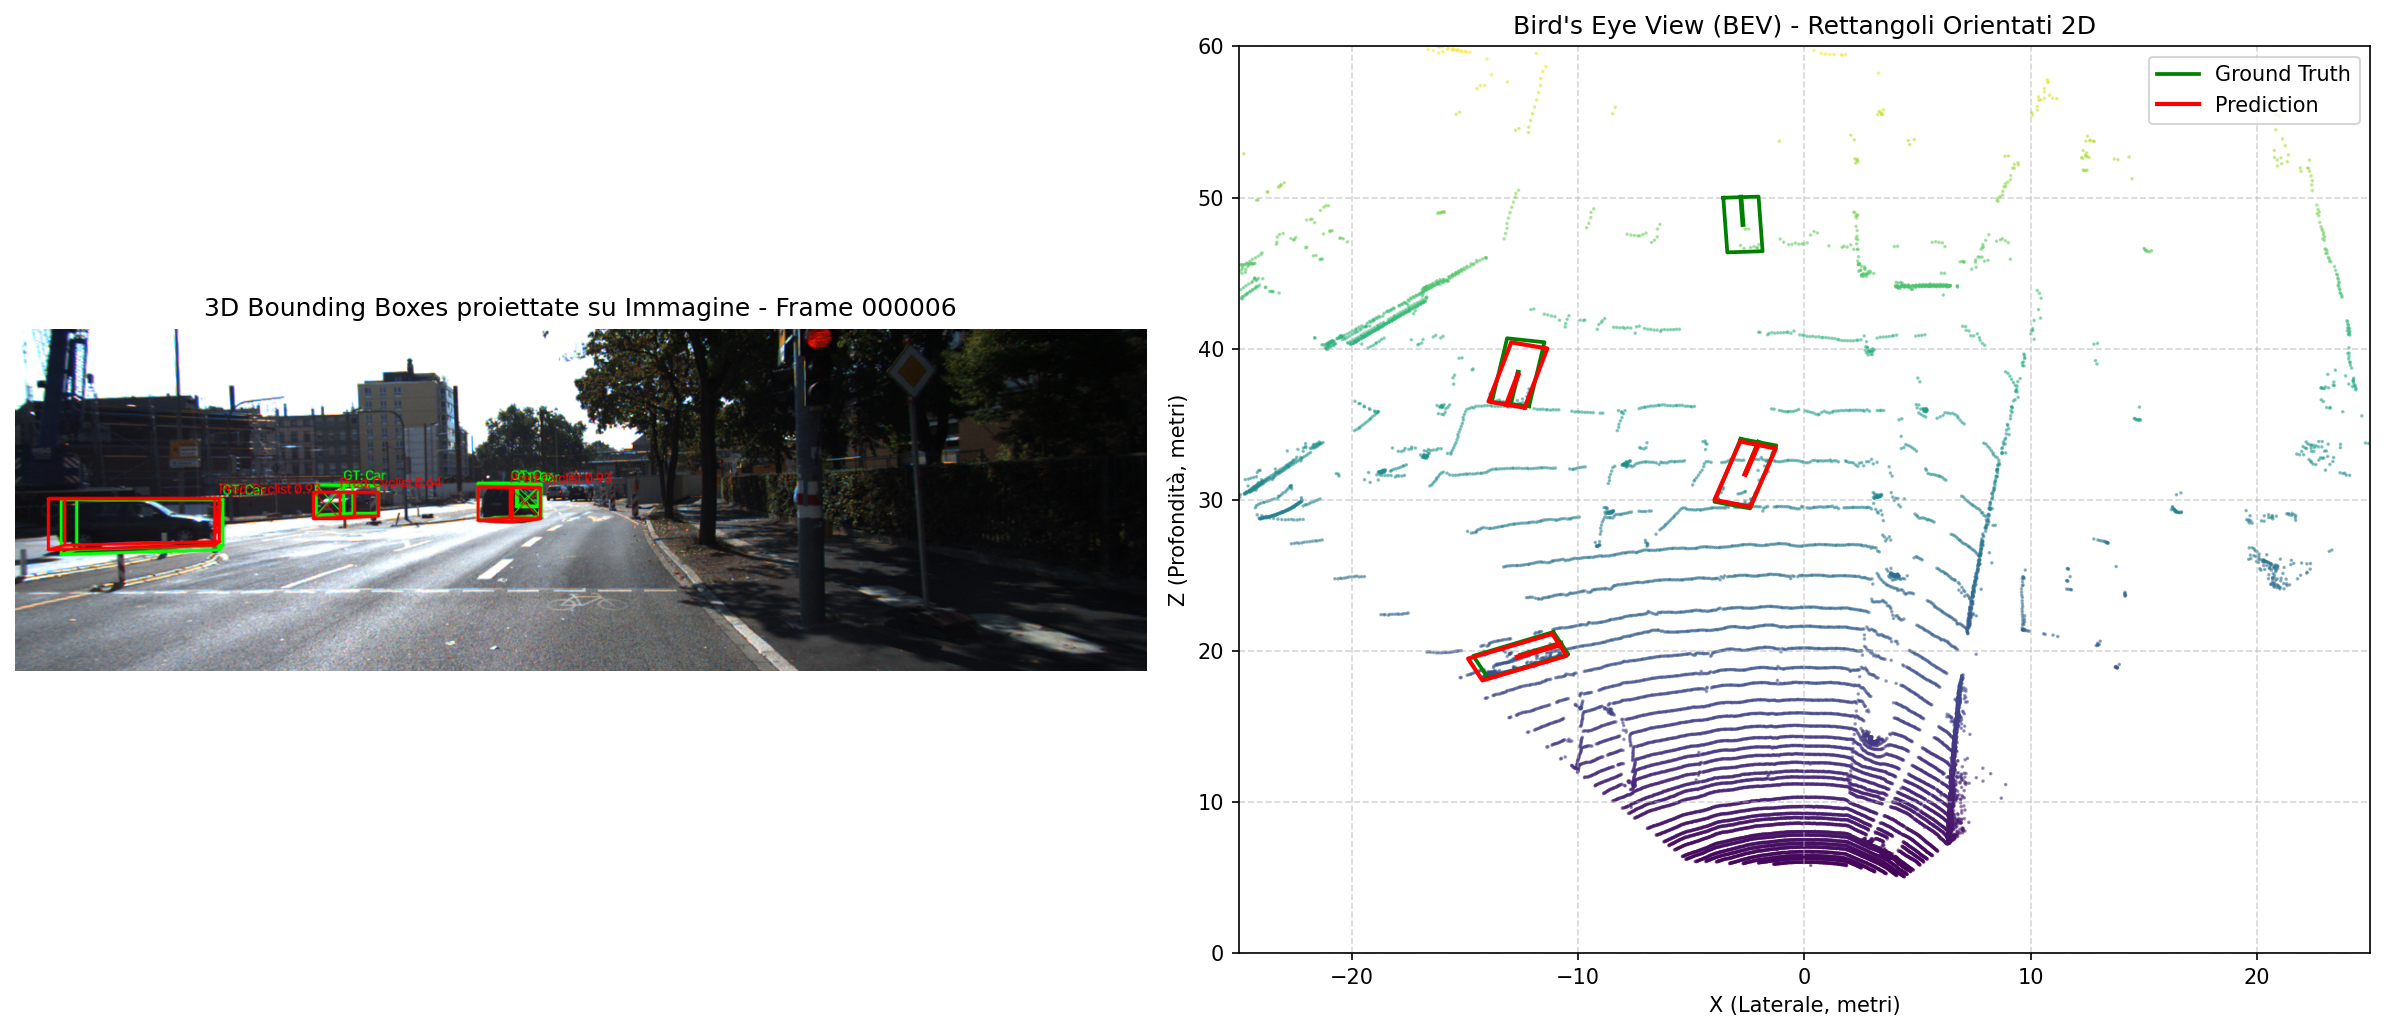

In [13]:
from IPython.display import Image
Image('prediction_result.png')